In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec


import os

import seaborn as sns



# Load data

In [2]:
# Load barcode dataframe 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_all_info.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,_3set_identified_by_atac
atac_bc,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO,common
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO,common


In [3]:
# Load fragments file
frag_file = os.path.join(entropy_dir, 'fragments.tsv')
frag = pd.read_csv(frag_file, sep='\t', index_col=3, header=None)
frag.index.name ='atac_BC'
frag.columns = ['chrom', 'start', 'end', 'support']
frag['atac_bc'] = frag.index.map(lambda x: x.split('-1')[0])
frag['frag_length'] = frag['end'] - frag['start']



In [4]:
frag_in_Raw_peak_file = os.path.join(Union_cell_subdir, 'Rawpeaks', 'frag_overlap/frag_in_peaks.tsv')

frag_in_Entropy_peak_file = os.path.join(Union_cell_subdir, 'Entropy_cells_peaks', 'frag_overlap/frag_in_peaks.tsv')
frag_in_TSS_peak_file = os.path.join(Union_cell_subdir, 'TSS_cells_peaks', 'frag_overlap/frag_in_peaks.tsv')
frag_in_FRIP_peak_file = os.path.join(Union_cell_subdir, 'FRIP_cells_peaks', 'frag_overlap/frag_in_peaks.tsv')


frag_in_raw_peaks = pd.read_csv(frag_in_Raw_peak_file, sep='\t', index_col=3, header=None)
frag_in_entropy_peaks = pd.read_csv(frag_in_Entropy_peak_file, sep='\t', index_col=3, header=None)
frag_in_tss_peaks = pd.read_csv(frag_in_TSS_peak_file, sep='\t', index_col=3, header=None)
frag_in_frip_peaks = pd.read_csv(frag_in_FRIP_peak_file, sep='\t', index_col=3, header=None)

for df in [frag_in_raw_peaks, frag_in_entropy_peaks, frag_in_tss_peaks, frag_in_frip_peaks]:
    df.index.name ='atac_BC'
    df.columns = ['chrom', 'start', 'end', 'support']
    df['atac_bc'] = df.index.map(lambda x: x.split('-1')[0])
    df['frag_length'] = df['end'] - df['start']

In [7]:
columns =['chrom', 'start', 'end', 'support'] 
frag_in_blacklist_file = os.path.join(Union_cell_subdir, 'frag_in_blacklist.tsv')
frag_in_blacklist = pd.read_csv(frag_in_blacklist_file, sep='\t', index_col=3, header=None)
frag_in_blacklist['atac_bc'] = frag_in_blacklist.index.map(lambda x: x.split('-1')[0])



# FRIP on each peak-set comparision among 3 cell-calling approaches

## FRIP distribution

In [5]:
total_frag_per_bc = union_cell_info.copy()
total_frag_per_bc['Nfrag_in_raw_peaks'] = total_frag_per_bc.index.map(frag_in_raw_peaks.groupby('atac_bc').size())
total_frag_per_bc['Nfrag_in_entropy_peaks'] = total_frag_per_bc.index.map(frag_in_entropy_peaks.groupby('atac_bc').size())
total_frag_per_bc['Nfrag_in_tss_peaks'] = total_frag_per_bc.index.map(frag_in_tss_peaks.groupby('atac_bc').size())
total_frag_per_bc['Nfrag_in_frip_peaks'] = total_frag_per_bc.index.map(frag_in_frip_peaks.groupby('atac_bc').size())

total_frag_per_bc['FRIP_raw_peaks'] = total_frag_per_bc['Nfrag_in_raw_peaks'] / total_frag_per_bc['total_fragments'] * 100 
total_frag_per_bc['FRIP_entropy_peaks'] = total_frag_per_bc['Nfrag_in_entropy_peaks'] / total_frag_per_bc['total_fragments'] * 100
total_frag_per_bc['FRIP_tss_peaks'] = total_frag_per_bc['Nfrag_in_tss_peaks'] / total_frag_per_bc['total_fragments'] * 100
total_frag_per_bc['FRIP_frip_peaks'] = total_frag_per_bc['Nfrag_in_frip_peaks'] / total_frag_per_bc['total_fragments'] * 100

In [6]:
total_frag_per_bc.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,_3set_identified_by_atac,Nfrag_in_raw_peaks,Nfrag_in_entropy_peaks,Nfrag_in_tss_peaks,Nfrag_in_frip_peaks,FRIP_raw_peaks,FRIP_entropy_peaks,FRIP_tss_peaks,FRIP_frip_peaks
atac_bc,,,,,,,,,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO,common,1729,1919,1933,1785,71.683250,79.560531,80.140962,74.004975
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO,common,1538,1847,1877,1635,17.032115,20.454042,20.786268,18.106312


In [7]:
frip_info_file = os.path.join(Union_cell_subdir, 'frip_cells_info.tsv')
total_frag_per_bc.to_csv(frip_info_file, sep='\t')

In [21]:

total_frag_per_bc['Nfrag_in_blacklist'] = total_frag_per_bc.index.map(frag_in_blacklist.groupby('atac_bc').size())
total_frag_per_bc['Nfrag_in_blacklist'] = total_frag_per_bc['Nfrag_in_blacklist'].fillna(0)
total_frag_per_bc['blacklist_ratio'] = total_frag_per_bc['Nfrag_in_blacklist'] / total_frag_per_bc['total_fragments'] 

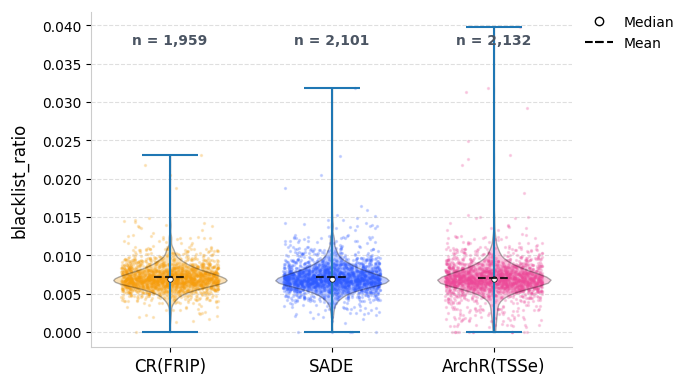

----- 	   CR 	 entropy_only 	 ArchR 
mean 	 ['0.0071', '0.0071', '0.0070']
median 	 ['0.0070', '0.0069', '0.0069']


In [26]:
def add_jittered_points(ax, data_group, position, jitter_width=0.3, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.2, s=2, zorder=1) # s controls point size

np.random.seed(999) # For reproducibility of jitter
fig, ax = plt.subplots(ncols=1, figsize=(7, 4))

width = 0.9
colors_map = ['#F59E0B', '#2E5BFF', '#EC4899', ]
labels_map = ['CR(FRIP)', 'SADE', 'ArchR(TSSe)']

frip_values = [ total_frag_per_bc['blacklist_ratio'].loc[total_frag_per_bc[cat] == True] for 
               cat in ['atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS'] ]
x_positions = range(len(frip_values))

for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])

v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=0.7, 
              showmedians=False, showmeans=False)

total_counts = [ frip.shape[0] for frip in frip_values ]
for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1] * 0.9, f'n = {count:,}', ha='center', 
            fontsize=10, color='#4B5563', fontweight='bold')

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.3)
    body.set_zorder(2)

# 4. Add "Inner Boxplot" elements for a premium look
for i, group_data in enumerate(frip_values):
    quartile1, median, quartile3 = np.percentile(group_data, [25, 50, 75])
    mean = np.mean(group_data)
    # Draw a thin line for the mean
    ax.hlines(mean, x_positions[i] - 0.1, x_positions[i] + 0.1, color='black', linestyle='--', lw=1.5, alpha=0.8, zorder=4)
    ax.scatter(x_positions[i], median, color='white', s=15, zorder=3, edgecolor='black', lw=0.5)

ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xticks(x_positions)
ax.set_xticklabels(labels_map, fontsize=12, fontweight='medium')
ax.set_ylabel('blacklist_ratio', fontsize=12, labelpad=10)
# ax.set_ylim(0, 105)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Median', markerfacecolor='white', markeredgecolor='black', markersize=6),
    Line2D([0], [0], marker='_', color='black', label='Mean', markersize=6, markeredgewidth=1.5, linestyle='--'),
]
ax.legend(handles=legend_elements, loc='lower left', frameon=False, fontsize=10, bbox_to_anchor=(1, 0.85))

plt.tight_layout()
plt.show()

mean_frip_values = [f'{np.mean(a):.4f}' for a in frip_values]
median_frip_values = [f'{np.median(a):.4f}' for a in frip_values]
print('----- \t   CR \t entropy_only \t ArchR ')
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

In [31]:
total_frag_per_bc['_3set_identified_by_atac'].unique()

array(['common', 'SADE+CR, not TSS', 'SADE+TSS, not CR', 'TSS unique',
       'CR+TSS, not SADE', 'SADE unique', 'CR unique'], dtype=object)

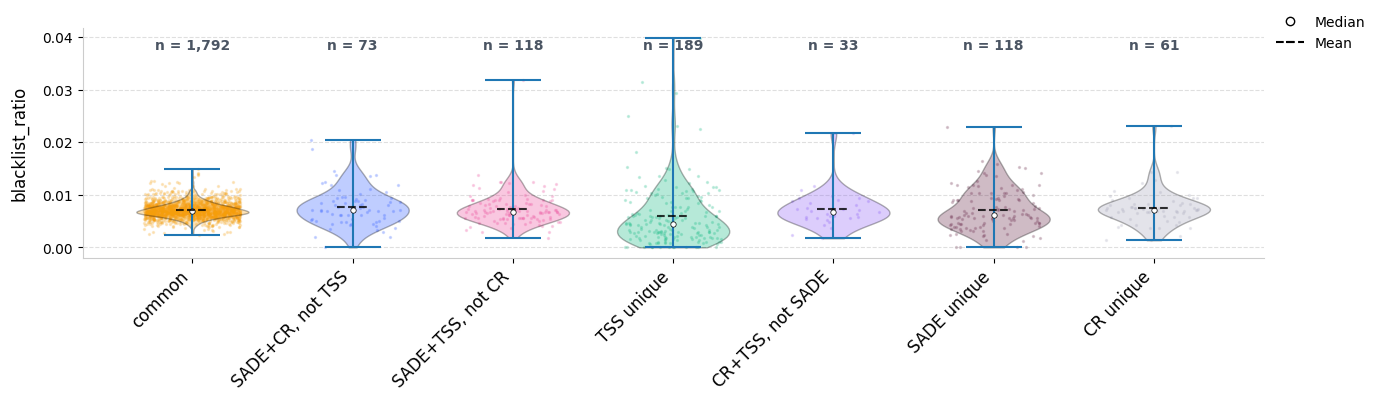

-----   common]  [SADE+CR, not TSS]  [SADE+TSS, not CR]  [TSS unique]  [CR+TSS, not SADE]  [SADE unique]  [CR unique
mean 	 ['0.007%  ', '0.008%  ', '0.007%  ', '0.006%  ', '0.007%  ', '0.007%  ', '0.007%  ']
median 	 ['0.007%  ', '0.007%  ', '0.007%  ', '0.004%  ', '0.007%  ', '0.006%  ', '0.007%  ']


In [46]:
def add_jittered_points(ax, data_group, position, jitter_width=0.3, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.2, s=2, zorder=1) # s controls point size

np.random.seed(999) # For reproducibility of jitter
fig, ax = plt.subplots(ncols=1, figsize=(14, 4))

width = 0.9
colors_map = ['#F59E0B', '#2E5BFF', '#EC4899', '#10B981', '#8B5CF6', "#611E41", "#A5A5BA"]
labels_map = ['common', 'SADE+CR, not TSS', 'SADE+TSS, not CR', 'TSS unique',
       'CR+TSS, not SADE', 'SADE unique', 'CR unique']

frip_values = [ total_frag_per_bc['blacklist_ratio'].loc[total_frag_per_bc['_3set_identified_by_atac'] == cat] for 
               cat in labels_map ]
x_positions = range(len(frip_values))

for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])

v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=0.7, 
              showmedians=False, showmeans=False)

total_counts = [ frip.shape[0] for frip in frip_values ]
for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1] * 0.9, f'n = {count:,}', ha='center', 
            fontsize=10, color='#4B5563', fontweight='bold')

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.3)
    body.set_zorder(2)

# 4. Add "Inner Boxplot" elements for a premium look
for i, group_data in enumerate(frip_values):
    quartile1, median, quartile3 = np.percentile(group_data, [25, 50, 75])
    mean = np.mean(group_data)
    # Draw a thin line for the mean
    ax.hlines(mean, x_positions[i] - 0.1, x_positions[i] + 0.1, color='black', linestyle='--', lw=1.5, alpha=0.8, zorder=4)
    ax.scatter(x_positions[i], median, color='white', s=15, zorder=3, edgecolor='black', lw=0.5)

ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xticks(x_positions)
ax.set_xticklabels(labels_map, fontsize=12, fontweight='medium', rotation=45, ha='right')
ax.set_ylabel('blacklist_ratio', fontsize=12, labelpad=10)
# ax.set_ylim(0, 105)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Median', markerfacecolor='white', markeredgecolor='black', markersize=6),
    Line2D([0], [0], marker='_', color='black', label='Mean', markersize=6, markeredgewidth=1.5, linestyle='--'),
]
ax.legend(handles=legend_elements, loc='lower left', frameon=False, fontsize=10, bbox_to_anchor=(1, 0.85))

plt.tight_layout()
plt.show()


mean_frip_values = [f'{np.mean(a):.3f}%  ' for a in frip_values]
median_frip_values = [f'{np.median(a):.3f}%  ' for a in frip_values]
print('-----   ' + ']  ['.join(labels_map))
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

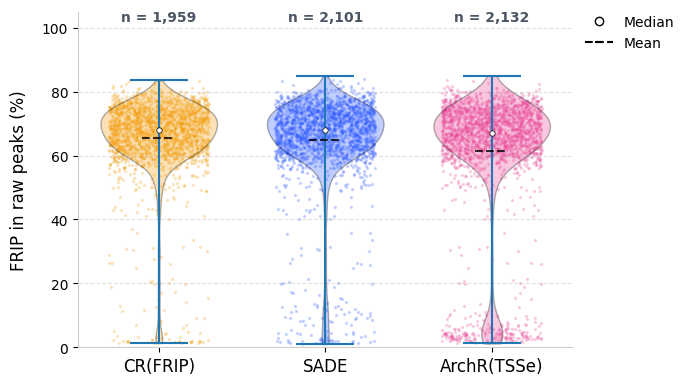

----- 	   CR 	 entropy_only 	 ArchR 
mean 	 ['65.45%', '64.85%', '61.32%']
median 	 ['67.96%', '67.97%', '67.15%']


In [8]:
def add_jittered_points(ax, data_group, position, jitter_width=0.3, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.2, s=2, zorder=1) # s controls point size



np.random.seed(999) # For reproducibility of jitter
fig, ax = plt.subplots(ncols=1, figsize=(7, 4))

width = 0.9
colors_map = ['#F59E0B', '#2E5BFF', '#EC4899', ]
labels_map = ['CR(FRIP)', 'SADE', 'ArchR(TSSe)']

frip_values = [ total_frag_per_bc['FRIP_raw_peaks'].loc[total_frag_per_bc[cat] == True] for 
               cat in ['atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS'] ]
x_positions = range(len(frip_values))

for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])

v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=0.7, 
              showmedians=False, showmeans=False)

total_counts = [ frip.shape[0] for frip in frip_values ]
for i, count in enumerate(total_counts):
    ax.text(x_positions[i], 102, f'n = {count:,}', ha='center', 
            fontsize=10, color='#4B5563', fontweight='bold')

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.3)
    body.set_zorder(2)

# 4. Add "Inner Boxplot" elements for a premium look
for i, group_data in enumerate(frip_values):
    quartile1, median, quartile3 = np.percentile(group_data, [25, 50, 75])
    mean = np.mean(group_data)
    # Draw a thin line for the mean
    ax.hlines(mean, x_positions[i] - 0.1, x_positions[i] + 0.1, color='black', linestyle='--', lw=1.5, alpha=0.8, zorder=4)
    ax.scatter(x_positions[i], median, color='white', s=15, zorder=3, edgecolor='black', lw=0.5)

ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xticks(x_positions)
ax.set_xticklabels(labels_map, fontsize=12, fontweight='medium')
ax.set_ylabel('FRIP in raw peaks (%)', fontsize=12, labelpad=10)
ax.set_ylim(0, 105)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Median', markerfacecolor='white', markeredgecolor='black', markersize=6),
    Line2D([0], [0], marker='_', color='black', label='Mean', markersize=6, markeredgewidth=1.5, linestyle='--'),
]
ax.legend(handles=legend_elements, loc='lower left', frameon=False, fontsize=10, bbox_to_anchor=(1, 0.85))

plt.tight_layout()
plt.show()

mean_frip_values = [f'{np.mean(a):.2f}%' for a in frip_values]
median_frip_values = [f'{np.median(a):.2f}%' for a in frip_values]
print('----- \t   CR \t entropy_only \t ArchR ')
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')


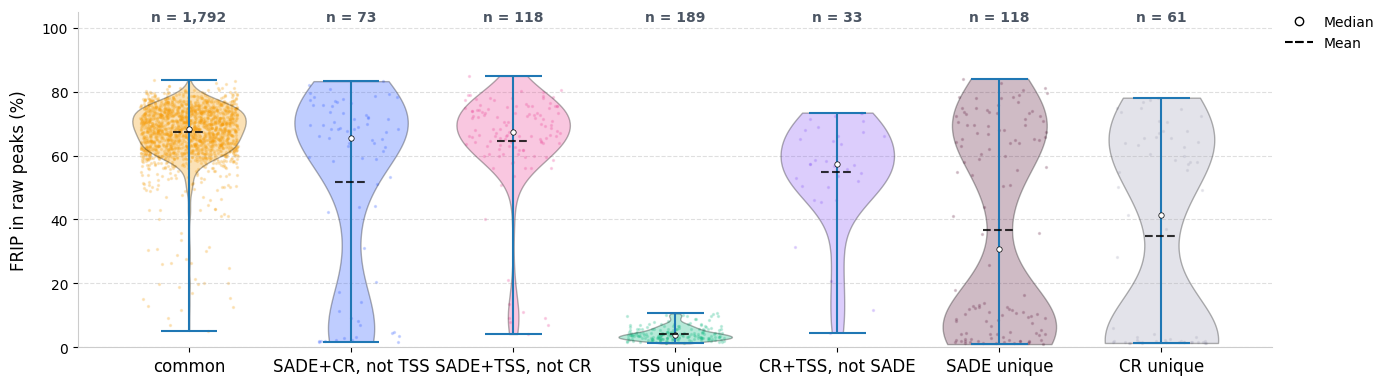

-----   common]  [SADE+CR, not TSS]  [SADE+TSS, not CR]  [TSS unique]  [CR+TSS, not SADE]  [SADE unique]  [CR unique
mean 	 ['67.237%  ', '51.849%  ', '64.602%  ', '4.292%  ', '54.916%  ', '36.826%  ', '34.837%  ']
median 	 ['68.319%  ', '65.625%  ', '67.528%  ', '3.746%  ', '57.325%  ', '30.633%  ', '41.292%  ']


In [45]:
def add_jittered_points(ax, data_group, position, jitter_width=0.3, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.2, s=2, zorder=1) # s controls point size



np.random.seed(999) # For reproducibility of jitter
fig, ax = plt.subplots(ncols=1, figsize=(14, 4))

width = 0.9
colors_map = ['#F59E0B', '#2E5BFF', '#EC4899', '#10B981', '#8B5CF6', "#611E41", "#A5A5BA"]
labels_map = ['common', 'SADE+CR, not TSS', 'SADE+TSS, not CR', 'TSS unique',
       'CR+TSS, not SADE', 'SADE unique', 'CR unique']


frip_values = [ total_frag_per_bc['FRIP_raw_peaks'].loc[total_frag_per_bc['_3set_identified_by_atac'] == cat] for 
               cat in labels_map ]
x_positions = range(len(frip_values))

for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])

v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=0.7, 
              showmedians=False, showmeans=False)

total_counts = [ frip.shape[0] for frip in frip_values ]
for i, count in enumerate(total_counts):
    ax.text(x_positions[i], 102, f'n = {count:,}', ha='center', 
            fontsize=10, color='#4B5563', fontweight='bold')

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.3)
    body.set_zorder(2)

# 4. Add "Inner Boxplot" elements for a premium look
for i, group_data in enumerate(frip_values):
    quartile1, median, quartile3 = np.percentile(group_data, [25, 50, 75])
    mean = np.mean(group_data)
    # Draw a thin line for the mean
    ax.hlines(mean, x_positions[i] - 0.1, x_positions[i] + 0.1, color='black', linestyle='--', lw=1.5, alpha=0.8, zorder=4)
    ax.scatter(x_positions[i], median, color='white', s=15, zorder=3, edgecolor='black', lw=0.5)

ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xticks(x_positions)
ax.set_xticklabels(labels_map, fontsize=12, fontweight='medium')
ax.set_ylabel('FRIP in raw peaks (%)', fontsize=12, labelpad=10)
ax.set_ylim(0, 105)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Median', markerfacecolor='white', markeredgecolor='black', markersize=6),
    Line2D([0], [0], marker='_', color='black', label='Mean', markersize=6, markeredgewidth=1.5, linestyle='--'),
]
ax.legend(handles=legend_elements, loc='lower left', frameon=False, fontsize=10, bbox_to_anchor=(1, 0.85))

plt.tight_layout()
plt.show()

mean_frip_values = [f'{np.mean(a):.3f}%  ' for a in frip_values]
median_frip_values = [f'{np.median(a):.3f}%  ' for a in frip_values]
print('-----   ' + ']  ['.join(labels_map))
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')


----- 	 CR_2ndRound 	 ArchR 	 entropy_only
mean 	 ['67.07%', '11.82%', '42.57%', '34.84%']
median 	 ['68.29%', '4.29%', '58.33%', '41.29%']


Text(0.5, 0.98, 'Comparison of SADE vs ArchR')

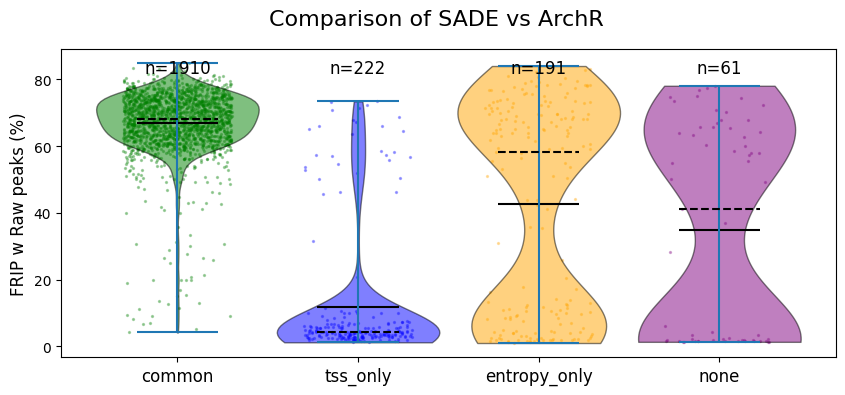

In [21]:
fig, ax = plt.subplots(ncols=1, figsize=(10, 4))

x_positions = range(4)
width = 0.9

colors_map = ['green', 'blue', 'orange', 'purple']
frip_values = [ total_frag_per_bc['FRIP_raw_peaks'].loc[total_frag_per_bc['_2set_identified_by_atac_ST'] == cat ] for cat in ['both', 'tss_only', 'entropy_only', 'none'] ]
total_counts = [ frip.shape[0] for frip in frip_values ]

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.3, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])


v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['common', 'tss_only', 'entropy_only', 'none'], 
                   rotation=0, ha='center', fontsize=12)
ax.set_ylabel('FRIP w Raw peaks (%)', fontsize=12)
# ax.set_ylim(19, 25)
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

mean_frip_values = [np.mean(a) for a in frip_values]
median_frip_values = [np.median(a) for a in frip_values]
mean_frip_values = [f'{mean:.2f}%' for mean in mean_frip_values]
median_frip_values = [f'{median:.2f}%' for median in median_frip_values]
print('----- \t CR_2ndRound \t ArchR \t entropy_only')
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

fig.suptitle('Comparison of SADE vs ArchR', fontsize=16)

----- 	 CR_2ndRound 	 ArchR 	 entropy_only
mean 	 ['66.63%', '41.89%', '50.71%', '4.29%']
median 	 ['68.28%', '55.14%', '64.44%', '3.75%']


Text(0.5, 0.98, 'Comparison of SADE vs CR')

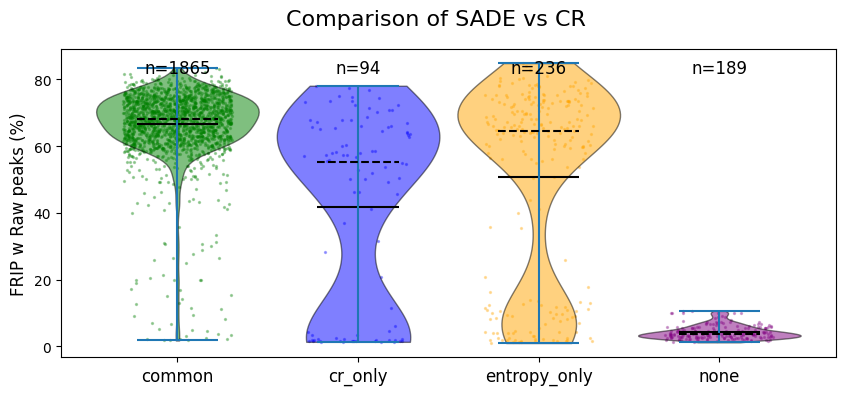

In [20]:
fig, ax = plt.subplots(ncols=1, figsize=(10, 4))

x_positions = range(4)
width = 0.9

colors_map = ['green', 'blue', 'orange', 'purple']
frip_values = [ total_frag_per_bc['FRIP_raw_peaks'].loc[total_frag_per_bc['_2set_identified_by_atac_SC'] == cat ] for cat in ['both', 'cr_only', 'entropy_only', 'none'] ]
total_counts = [ frip.shape[0] for frip in frip_values ]

np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.3, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])


v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['common', 'cr_only', 'entropy_only', 'none'], 
                   rotation=0, ha='center', fontsize=12)
ax.set_ylabel('FRIP w Raw peaks (%)', fontsize=12)
# ax.set_ylim(19, 25)
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)


mean_frip_values = [np.mean(a) for a in frip_values]
median_frip_values = [np.median(a) for a in frip_values]
mean_frip_values = [f'{mean:.2f}%' for mean in mean_frip_values]
median_frip_values = [f'{median:.2f}%' for median in median_frip_values]

print('----- \t CR_2ndRound \t ArchR \t entropy_only')
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

fig.suptitle('Comparison of SADE vs CR', fontsize=16)

## On the whole peak-set

/tmp/ipykernel_187057/957562121.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[0].scatter(total_frag_per_bc[f'Nfrag_in_{xlabel}'],
/tmp/ipykernel_187057/957562121.py:16: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[1].scatter(total_frag_per_bc[f'Nfrag_in_{xlabel}'],
/tmp/ipykernel_187057/957562121.py:27: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[2].scatter(total_frag_per_bc[f'Nfrag_in_{xlabel}'],


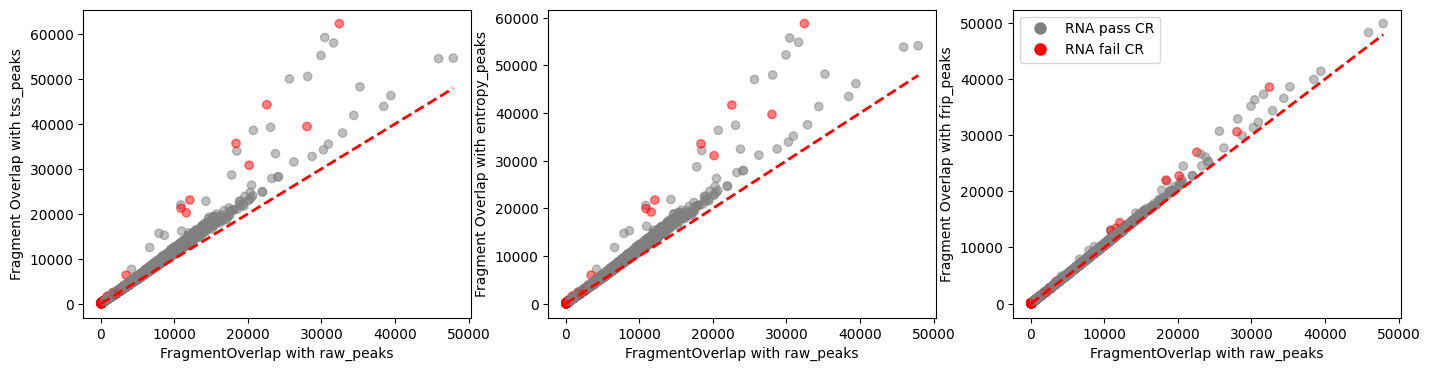

In [11]:
fig, ax = plt.subplots(ncols=3, figsize=(17, 4))

ylabel = 'tss_peaks'
xlabel = 'raw_peaks'
ax[0].scatter(total_frag_per_bc[f'Nfrag_in_{xlabel}'], 
           total_frag_per_bc[f'Nfrag_in_{ylabel}'], 
           c =total_frag_per_bc['rna_pass_CR'].map({True: 'grey', False: 'red'}), cmap='Set1', alpha=0.5)
ax[0].set_xlabel(f'FragmentOverlap with {xlabel}')
ax[0].set_ylabel(f'Fragment Overlap with {ylabel}')
vmax = total_frag_per_bc[f'Nfrag_in_{xlabel}'].max()
ax[0].plot([0, vmax], [0, vmax],  color='red', linestyle='--', linewidth=2)


ylabel = 'entropy_peaks'
xlabel = 'raw_peaks'
ax[1].scatter(total_frag_per_bc[f'Nfrag_in_{xlabel}'], 
           total_frag_per_bc[f'Nfrag_in_{ylabel}'], 
           c =total_frag_per_bc['rna_pass_CR'].map({True: 'grey', False: 'red'}), cmap='Set1', alpha=0.5)
ax[1].set_xlabel(f'FragmentOverlap with {xlabel}')
ax[1].set_ylabel(f'Fragment Overlap with {ylabel}')
vmax = total_frag_per_bc[f'Nfrag_in_{xlabel}'].max()
ax[1].plot([0, vmax], [0, vmax],  color='red', linestyle='--', linewidth=2)


ylabel = 'frip_peaks'
xlabel = 'raw_peaks'
ax[2].scatter(total_frag_per_bc[f'Nfrag_in_{xlabel}'], 
           total_frag_per_bc[f'Nfrag_in_{ylabel}'], 
           c =total_frag_per_bc['rna_pass_CR'].map({True: 'grey', False: 'red'}), cmap='Set1', alpha=0.5)
ax[2].set_xlabel(f'FragmentOverlap with {xlabel}')
ax[2].set_ylabel(f'Fragment Overlap with {ylabel}')
vmax = total_frag_per_bc[f'Nfrag_in_{xlabel}'].max()
ax[2].plot([0, vmax], [0, vmax],  color='red', linestyle='--', linewidth=2)

ax[2].legend(handles=[Line2D([0], [0], marker='o', color='w', label='RNA pass CR', markerfacecolor='grey', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='RNA fail CR', markerfacecolor='red', markersize=10)], loc='upper left')

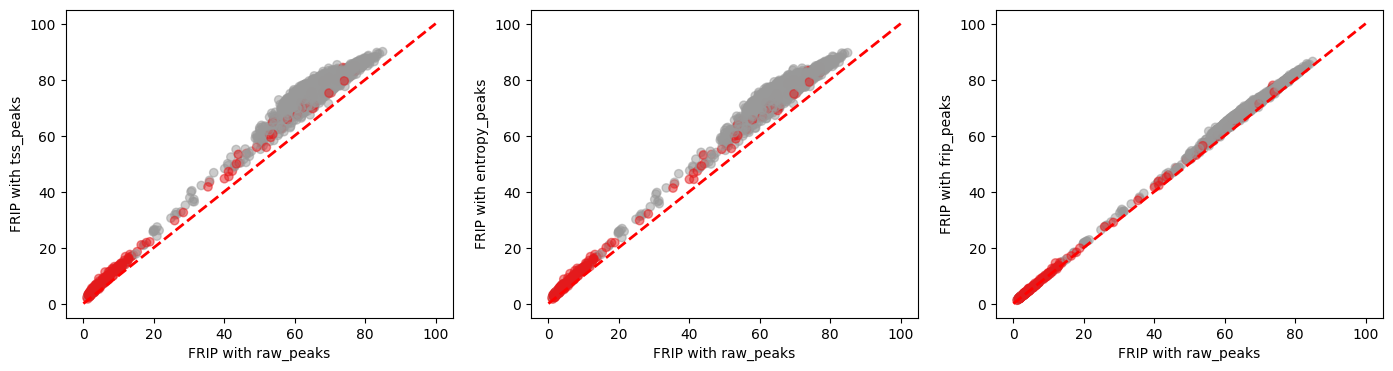

In [12]:
fig, ax = plt.subplots(ncols=3, figsize=(17, 4))

ylabel = 'tss_peaks'
xlabel = 'raw_peaks'
ax[0].scatter(total_frag_per_bc[f'FRIP_{xlabel}'], 
           total_frag_per_bc[f'FRIP_{ylabel}'],
           c =total_frag_per_bc['rna_pass_CR'], cmap='Set1', alpha=0.5)
ax[0].set_xlabel(f'FRIP with {xlabel}')
ax[0].set_ylabel(f'FRIP with {ylabel}')


ylabel = 'entropy_peaks'
xlabel = 'raw_peaks'
ax[1].scatter(total_frag_per_bc[f'FRIP_{xlabel}'], 
           total_frag_per_bc[f'FRIP_{ylabel}'], 
           c =total_frag_per_bc['rna_pass_CR'], cmap='Set1', alpha=0.5)
ax[1].set_xlabel(f'FRIP with {xlabel}')
ax[1].set_ylabel(f'FRIP with {ylabel}')

ylabel = 'frip_peaks'
xlabel = 'raw_peaks'
ax[2].scatter(total_frag_per_bc[f'FRIP_{xlabel}'], 
           total_frag_per_bc[f'FRIP_{ylabel}'], 
           c =total_frag_per_bc['rna_pass_CR'], cmap='Set1', alpha=0.5)
ax[2].set_xlabel(f'FRIP with {xlabel}')
ax[2].set_ylabel(f'FRIP with {ylabel}')

for a in ax:
    a.plot([0, 100], [0, 100],  color='red', linestyle='--', linewidth=2)

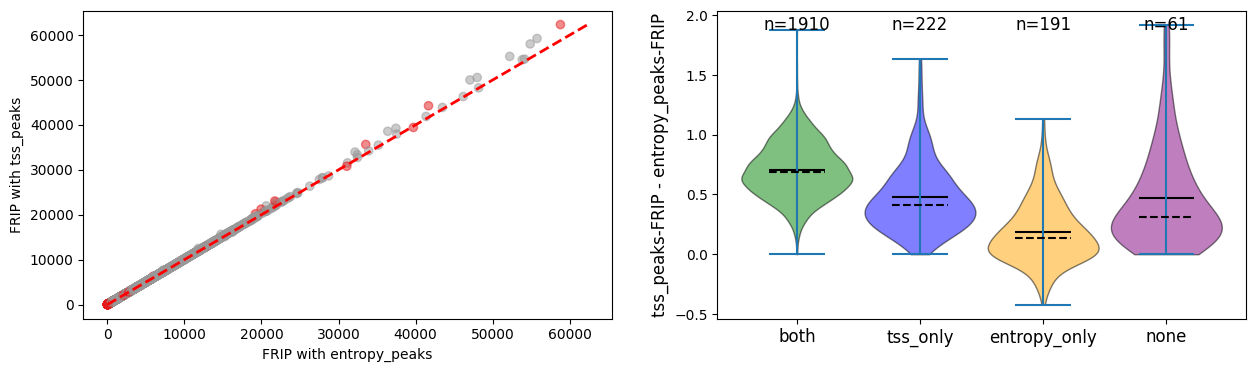

In [13]:
fig, ax = plt.subplots(ncols=2, figsize=(15, 4))  
xlabel = 'entropy_peaks'
ylabel = 'tss_peaks'
ax[0].scatter(total_frag_per_bc[f'Nfrag_in_{xlabel}'], 
              total_frag_per_bc[f'Nfrag_in_{ylabel}'], 
              c =total_frag_per_bc['rna_pass_CR'], cmap='Set1', alpha=0.5)
ax[0].set_xlabel(f'FRIP with {xlabel}')
ax[0].set_ylabel(f'FRIP with {ylabel}')

vmax = max(total_frag_per_bc[f'Nfrag_in_{xlabel}'].max(), total_frag_per_bc[f'Nfrag_in_{ylabel}'].max())
ax[0].plot([0, vmax], [0, vmax],  color='red', linestyle='--', linewidth=2)



x_positions = range(4)
width = 0.9

colors_map = ['green', 'blue', 'orange', 'purple']
frip_values = [ total_frag_per_bc[f'FRIP_{ylabel}'].loc[total_frag_per_bc['_2set_identified_by_atac_ST'] == cat ] - \
                total_frag_per_bc[f'FRIP_{xlabel}'].loc[total_frag_per_bc['_2set_identified_by_atac_ST'] == cat ] 
               for cat in ['both', 'tss_only', 'entropy_only', 'none'] ]
total_counts = [ frip.shape[0] for frip in frip_values ]


v1 = ax[1].violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax[1].set_xticks(x_positions)
ax[1].set_xticklabels(['both', 'tss_only', 'entropy_only', 'none'], 
                   rotation=0, ha='center', fontsize=12)
ax[1].set_ylabel(f'{ylabel}-FRIP - {xlabel}-FRIP', fontsize=12)


for i, count in enumerate(total_counts):
    ax[1].text(x_positions[i], ax[1].get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

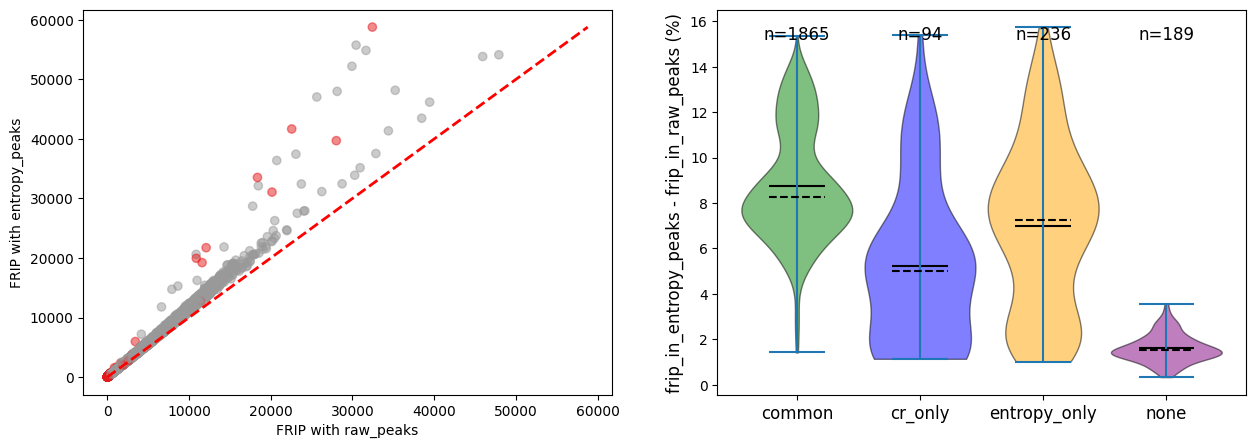

In [14]:
fig, ax = plt.subplots(ncols=2, figsize=(15, 5))  
ylabel = 'entropy_peaks'
xlabel = 'raw_peaks'
ax[0].scatter(total_frag_per_bc[f'Nfrag_in_{xlabel}'], 
              total_frag_per_bc[f'Nfrag_in_{ylabel}'], 
              c =total_frag_per_bc['rna_pass_CR'], cmap='Set1', alpha=0.5)
ax[0].set_xlabel(f'FRIP with {xlabel}')
ax[0].set_ylabel(f'FRIP with {ylabel}')

vmax = max(total_frag_per_bc[f'Nfrag_in_{xlabel}'].max(), total_frag_per_bc[f'Nfrag_in_{ylabel}'].max())
ax[0].plot([0, vmax], [0, vmax],  color='red', linestyle='--', linewidth=2)



x_positions = range(4)
width = 0.9

colors_map = ['green', 'blue', 'orange', 'purple']
frip_values = [ total_frag_per_bc[f'FRIP_{ylabel}'].loc[total_frag_per_bc['_2set_identified_by_atac_SC'] == cat ] - \
                total_frag_per_bc[f'FRIP_{xlabel}'].loc[total_frag_per_bc['_2set_identified_by_atac_SC'] == cat ] 
               for cat in ['both', 'cr_only', 'entropy_only', 'none'] ]
total_counts = [ frip.shape[0] for frip in frip_values ]


v1 = ax[1].violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax[1].set_xticks(x_positions)
ax[1].set_xticklabels(['common', 'cr_only', 'entropy_only', 'none'], 
                   rotation=0, ha='center', fontsize=12)
ax[1].set_ylabel(f'frip_in_{ylabel} - frip_in_{xlabel} (%)', fontsize=12)


for i, count in enumerate(total_counts):
    ax[1].text(x_positions[i], ax[1].get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

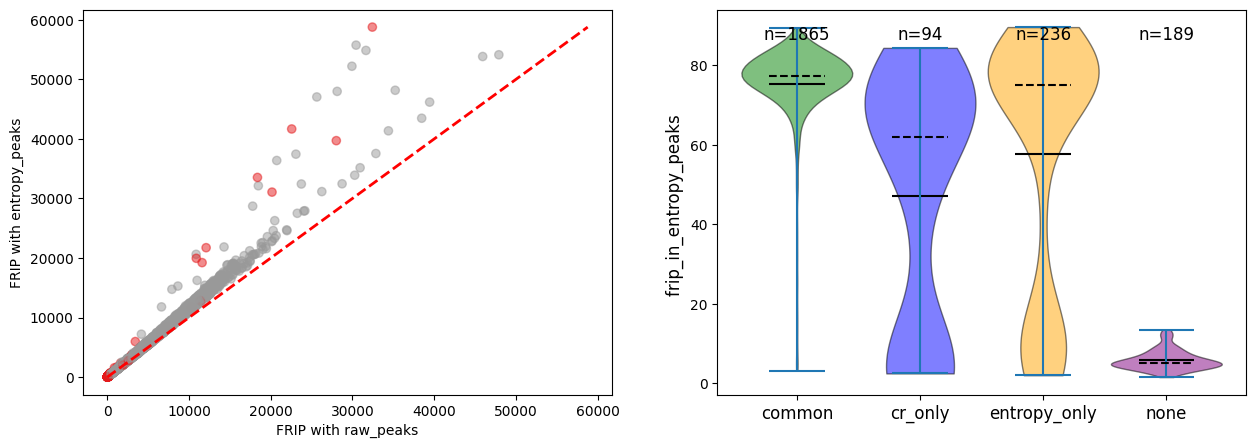

In [15]:
fig, ax = plt.subplots(ncols=2, figsize=(15, 5))  
ylabel = 'entropy_peaks'
xlabel = 'raw_peaks'
ax[0].scatter(total_frag_per_bc[f'Nfrag_in_{xlabel}'], 
              total_frag_per_bc[f'Nfrag_in_{ylabel}'], 
              c =total_frag_per_bc['rna_pass_CR'], cmap='Set1', alpha=0.5)
ax[0].set_xlabel(f'FRIP with {xlabel}')
ax[0].set_ylabel(f'FRIP with {ylabel}')

vmax = max(total_frag_per_bc[f'Nfrag_in_{xlabel}'].max(), total_frag_per_bc[f'Nfrag_in_{ylabel}'].max())
ax[0].plot([0, vmax], [0, vmax],  color='red', linestyle='--', linewidth=2)



x_positions = range(4)
width = 0.9

colors_map = ['green', 'blue', 'orange', 'purple']
frip_values = [ total_frag_per_bc[f'FRIP_{ylabel}'].loc[total_frag_per_bc['_2set_identified_by_atac_SC'] == cat ] 
               for cat in ['both', 'cr_only', 'entropy_only', 'none'] ]
total_counts = [ frip.shape[0] for frip in frip_values ]


v1 = ax[1].violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax[1].set_xticks(x_positions)
ax[1].set_xticklabels(['common', 'cr_only', 'entropy_only', 'none'], 
                   rotation=0, ha='center', fontsize=12)
ax[1].set_ylabel(f'frip_in_{ylabel} ', fontsize=12)


for i, count in enumerate(total_counts):
    ax[1].text(x_positions[i], ax[1].get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

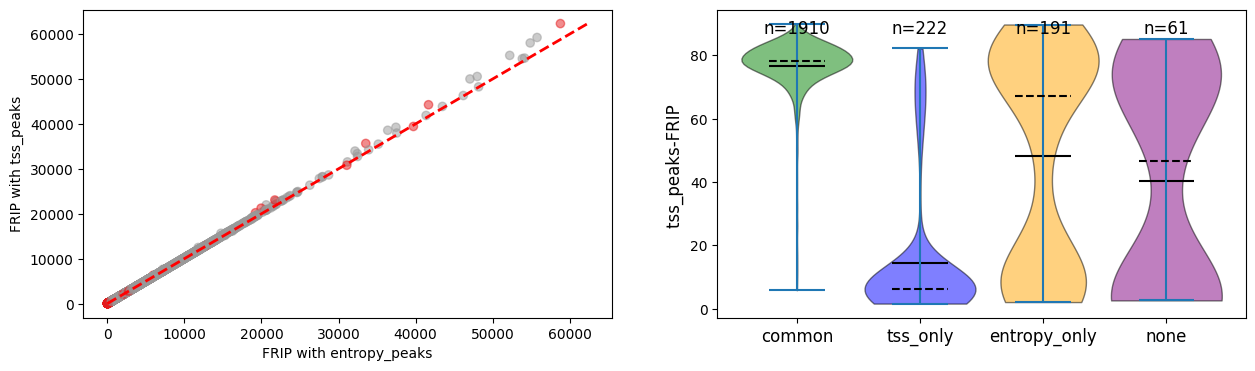

In [16]:
fig, ax = plt.subplots(ncols=2, figsize=(15, 4))  
xlabel = 'entropy_peaks'
ylabel = 'tss_peaks'
ax[0].scatter(total_frag_per_bc[f'Nfrag_in_{xlabel}'], 
              total_frag_per_bc[f'Nfrag_in_{ylabel}'], 
              c =total_frag_per_bc['rna_pass_CR'], cmap='Set1', alpha=0.5)
ax[0].set_xlabel(f'FRIP with {xlabel}')
ax[0].set_ylabel(f'FRIP with {ylabel}')

vmax = max(total_frag_per_bc[f'Nfrag_in_{xlabel}'].max(), total_frag_per_bc[f'Nfrag_in_{ylabel}'].max())
ax[0].plot([0, vmax], [0, vmax],  color='red', linestyle='--', linewidth=2)



x_positions = range(4)
width = 0.9

colors_map = ['green', 'blue', 'orange', 'purple']
frip_values = [ total_frag_per_bc[f'FRIP_{ylabel}'].loc[total_frag_per_bc['_2set_identified_by_atac_ST'] == cat ] 
               for cat in ['both', 'tss_only', 'entropy_only', 'none'] ]
total_counts = [ frip.shape[0] for frip in frip_values ]


v1 = ax[1].violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax[1].set_xticks(x_positions)
ax[1].set_xticklabels(['common', 'tss_only', 'entropy_only', 'none'], 
                   rotation=0, ha='center', fontsize=12)
ax[1].set_ylabel(f'{ylabel}-FRIP ', fontsize=12)


for i, count in enumerate(total_counts):
    ax[1].text(x_positions[i], ax[1].get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

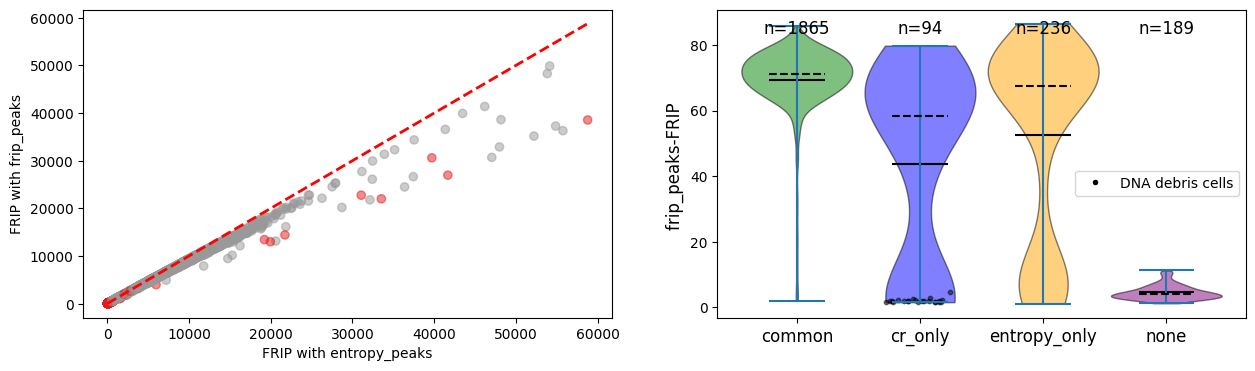

In [17]:

fig, ax = plt.subplots(ncols=2, figsize=(15, 4))  
xlabel = 'entropy_peaks'
ylabel = 'frip_peaks'
ax[0].scatter(total_frag_per_bc[f'Nfrag_in_{xlabel}'], 
              total_frag_per_bc[f'Nfrag_in_{ylabel}'], 
              c =total_frag_per_bc['rna_pass_CR'], cmap='Set1', alpha=0.5)
ax[0].set_xlabel(f'FRIP with {xlabel}')
ax[0].set_ylabel(f'FRIP with {ylabel}')

vmax = max(total_frag_per_bc[f'Nfrag_in_{xlabel}'].max(), total_frag_per_bc[f'Nfrag_in_{ylabel}'].max())
ax[0].plot([0, vmax], [0, vmax],  color='red', linestyle='--', linewidth=2)



x_positions = range(4)
width = 0.9

colors_map = ['green', 'blue', 'orange', 'purple']
frip_values = [ total_frag_per_bc[f'FRIP_{ylabel}'].loc[total_frag_per_bc['_2set_identified_by_atac_SC'] == cat ] 
               for cat in ['both', 'cr_only', 'entropy_only', 'none'] ]
total_counts = [ frip.shape[0] for frip in frip_values ]


v1 = ax[1].violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 


ax[1].set_xticks(x_positions)
ax[1].set_xticklabels(['common', 'cr_only', 'entropy_only', 'none'], 
                   rotation=0, ha='center', fontsize=12)
ax[1].set_ylabel(f'{ylabel}-FRIP ', fontsize=12)


for i, count in enumerate(total_counts):
    ax[1].text(x_positions[i], ax[1].get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)



DNA_debris_cells = total_frag_per_bc.loc[total_frag_per_bc['DNA_debris'] == 'YES'].copy()

np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.3, color='orange'):

    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.5, s=10) # s controls point size

DNA_debris_frip_values = [ DNA_debris_cells[f'FRIP_{ylabel}'].loc[DNA_debris_cells['_2set_identified_by_atac_SC'] == cat ] for 
                          cat in ['both', 'cr_only', 'entropy_only', 'none'] ]
for i, group_data in enumerate(DNA_debris_frip_values):
    add_jittered_points(ax[1], group_data, x_positions[i], color='black')


ax[1].legend(handles=[Line2D([0], [0], marker='o', color='w', label='DNA debris cells', markerfacecolor='black', markersize=5)], 
             loc='upper right', bbox_to_anchor=(1, 0.5))


In [18]:
entropy_stat_file = os.path.join(entropy_dir, 'calculated_barcode_entropy_wDNAdebrisflag_df.tsv')
entropy_stats_df = pd.read_csv(entropy_stat_file, sep=',', index_col=0)
entropy_stats_df['atac_bc'] = entropy_stats_df.index.map(lambda x: x.split('-1')[0])
entropy_stats_df.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,atac_bc
CAGGTTACAGCCTAAA-1,0.005184,2.345061,28,1.782331,0.168245,0.999594,NO,CAGGTTACAGCCTAAA
GAACAATGTCGGTTAT-1,0.203897,0.735687,449,0.185787,0.830450,0.968089,NO,GAACAATGTCGGTTAT


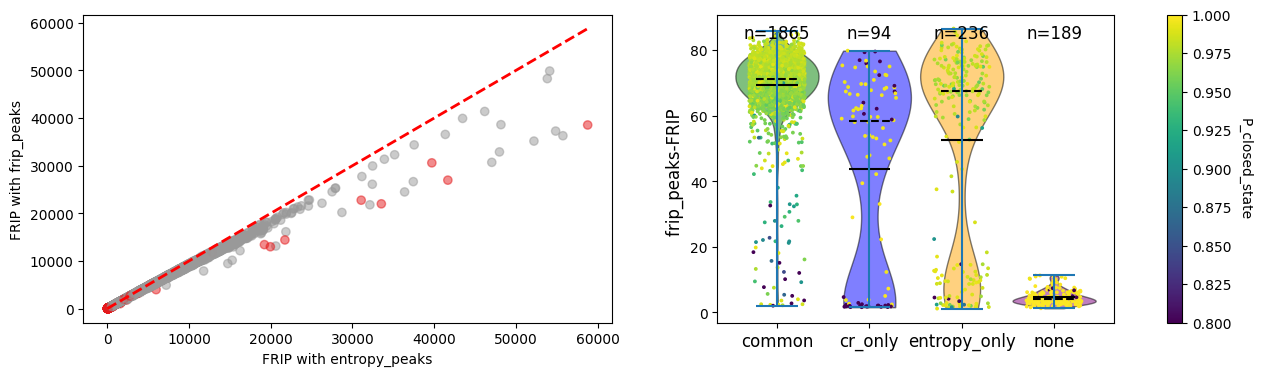

In [19]:

fig, ax = plt.subplots(ncols=2, figsize=(15, 4))  
xlabel = 'entropy_peaks'
ylabel = 'frip_peaks'
ax[0].scatter(total_frag_per_bc[f'Nfrag_in_{xlabel}'], 
              total_frag_per_bc[f'Nfrag_in_{ylabel}'], 
              c =total_frag_per_bc['rna_pass_CR'], cmap='Set1', alpha=0.5)
ax[0].set_xlabel(f'FRIP with {xlabel}')
ax[0].set_ylabel(f'FRIP with {ylabel}')

vmax = max(total_frag_per_bc[f'Nfrag_in_{xlabel}'].max(), total_frag_per_bc[f'Nfrag_in_{ylabel}'].max())
ax[0].plot([0, vmax], [0, vmax],  color='red', linestyle='--', linewidth=2)



x_positions = range(4)
width = 0.9

colors_map = ['green', 'blue', 'orange', 'purple']
frip_values = [ total_frag_per_bc[f'FRIP_{ylabel}'].loc[total_frag_per_bc['_2set_identified_by_atac_SC'] == cat ] 
               for cat in ['both', 'cr_only', 'entropy_only', 'none'] ]
total_counts = [ frip.shape[0] for frip in frip_values ]


v1 = ax[1].violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 


ax[1].set_xticks(x_positions)
ax[1].set_xticklabels(['common', 'cr_only', 'entropy_only', 'none'], 
                   rotation=0, ha='center', fontsize=12)
ax[1].set_ylabel(f'{ylabel}-FRIP ', fontsize=12)


for i, count in enumerate(total_counts):
    ax[1].text(x_positions[i], ax[1].get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)




np.random.seed(999)
def add_jittered_points(ax, data_group, position, color_values, jitter_width=0.3,  vmin=0.8, vmax=1):
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, c=color_values,  vmin=vmin, vmax=vmax, 
               alpha=1, s=3) # s controls point size

vmin, vmax = 0.8, 1 # for P_closed_state

for i, group_data in enumerate(frip_values):
    color_values = group_data.index.map( entropy_stats_df.set_index('atac_bc')[ 'P_closed_state']).fillna(-1)
    scatter = add_jittered_points(ax[1], group_data, x_positions[i], color_values=color_values, 
                                  vmin=vmin, vmax=vmax)

# Add colorbar 
norm = plt.Normalize(vmin=vmin, vmax=vmax)
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='viridis'), ax=ax[1], pad=0.1)
cbar.set_label('P_closed_state', rotation=270, labelpad=15)

## 